<a href="https://colab.research.google.com/github/Minetriforce/DL_project_traffic_signs/blob/main/project_traffic_signs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Partie 1 — Recherche, compréhension et préparation des données**

## **Description du dataset**


**GTSRB — German Traffic Sign Recognition Benchmark**

| Élément | Valeur |
|---|---|
| Source officielle | Institut für Neuroinformatik (INI), Ruhr-Universität Bochum : https://benchmark.ini.rub.de/ |
| Copie utilisée | Kaggle : https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign |
| Auteurs / référence | J. Stallkamp, M. Schlipsing, J. Salmen, C. Igel, *Man vs. computer: Benchmarking machine learning algorithms for traffic sign recognition*, Neural Networks, 2012 |
| Origine | Photos réelles de panneaux allemands, extraites de séquences vidéo prises sur route |
| Nombre de classe | 43 |
| Taille | 39 209 images d'entraînement + 12 630 images de test (≈ 51 800 au total) |
| Format | Images couleur RGB, fichiers `.png` (copie Kaggle), avec des CSV d'annotations (taille, zone du panneau, classe) |
| Dimensions | Variables : d'environ 15×15 à 250×250 pixels |
| Licence | Creative Commons Attribution 4.0 International (CC-BY-4.0)


**Pourquoi ce choix ?** Dataset de référence, bien documenté, assez grand pour entraîner un CNN, avec de vraies difficultés
(luminosité, flou, petite taille, classes proches comme les limitations de vitesse) qui nourriront les parties 5 et 6.

In [1]:
import kagglehub
import os
import matplotlib.pyplot as plt

#kagglehub.login()
DATA_PATH = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(DATA_PATH)
print(os.listdir(DATA_PATH))


Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
/kaggle/input/gtsrb-german-traffic-sign
['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [29]:
DATA_PATH_TRAIN = os.path.join(DATA_PATH, 'Train')
DATA_PATH_TEST = os.path.join(DATA_PATH, 'Test')
DATA_PATH_META = os.path.join(DATA_PATH, 'Meta')

print(DATA_PATH_TRAIN)
print(DATA_PATH_TEST)
print(DATA_PATH_META)
NUM_CLASSES = 43
IMG_SIZE = 32 # Redimensionnement standard

CLASSES = {
 0:"Limitation 20 km/h", 1:"Limitation 30 km/h", 2:"Limitation 50 km/h", 3:"Limitation 60 km/h",
 4:"Limitation 70 km/h", 5:"Limitation 80 km/h", 6:"Fin de limitation 80 km/h", 7:"Limitation 100 km/h",
 8:"Limitation 120 km/h", 9:"Interdiction de dépasser", 10:"Interdiction de dépasser (camions)",
 11:"Intersection avec priorité", 12:"Route prioritaire", 13:"Cédez le passage", 14:"STOP",
 15:"Circulation interdite", 16:"Interdit aux camions", 17:"Sens interdit", 18:"Danger général",
 19:"Virage dangereux à gauche", 20:"Virage dangereux à droite", 21:"Succession de virages",
 22:"Chaussée déformée", 23:"Chaussée glissante", 24:"Chaussée rétrécie (droite)", 25:"Travaux",
 26:"Feux tricolores", 27:"Passage piétons", 28:"Enfants", 29:"Cyclistes", 30:"Verglas / neige",
 31:"Animaux sauvages", 32:"Fin de toutes interdictions", 33:"Obligation : à droite",
 34:"Obligation : à gauche", 35:"Obligation : tout droit", 36:"Obligation : tout droit ou droite",
 37:"Obligation : tout droit ou gauche", 38:"Garder la droite", 39:"Garder la gauche",
 40:"Rond-point", 41:"Fin interdiction de dépasser", 42:"Fin interdiction de dépasser (camions)"}

print("Nombre de classes : ", NUM_CLASSES)

/kaggle/input/gtsrb-german-traffic-sign/Train
/kaggle/input/gtsrb-german-traffic-sign/Test
/kaggle/input/gtsrb-german-traffic-sign/Meta
Nombre de classes :  43


0    | Limitation 20 km/h                       | 210
1    | Limitation 30 km/h                       | 2220
2    | Limitation 50 km/h                       | 2250
3    | Limitation 60 km/h                       | 1410
4    | Limitation 70 km/h                       | 1980
5    | Limitation 80 km/h                       | 1860
6    | Fin de limitation 80 km/h                | 420
7    | Limitation 100 km/h                      | 1440
8    | Limitation 120 km/h                      | 1410
9    | Interdiction de dépasser                 | 1470
10   | Interdiction de dépasser (camions)       | 2010
11   | Intersection avec priorité               | 1320
12   | Route prioritaire                        | 2100
13   | Cédez le passage                         | 2160
14   | STOP                                     | 780
15   | Circulation interdite                    | 630
16   | Interdit aux camions                     | 420
17   | Sens interdit                            | 1110
18   | Danger g

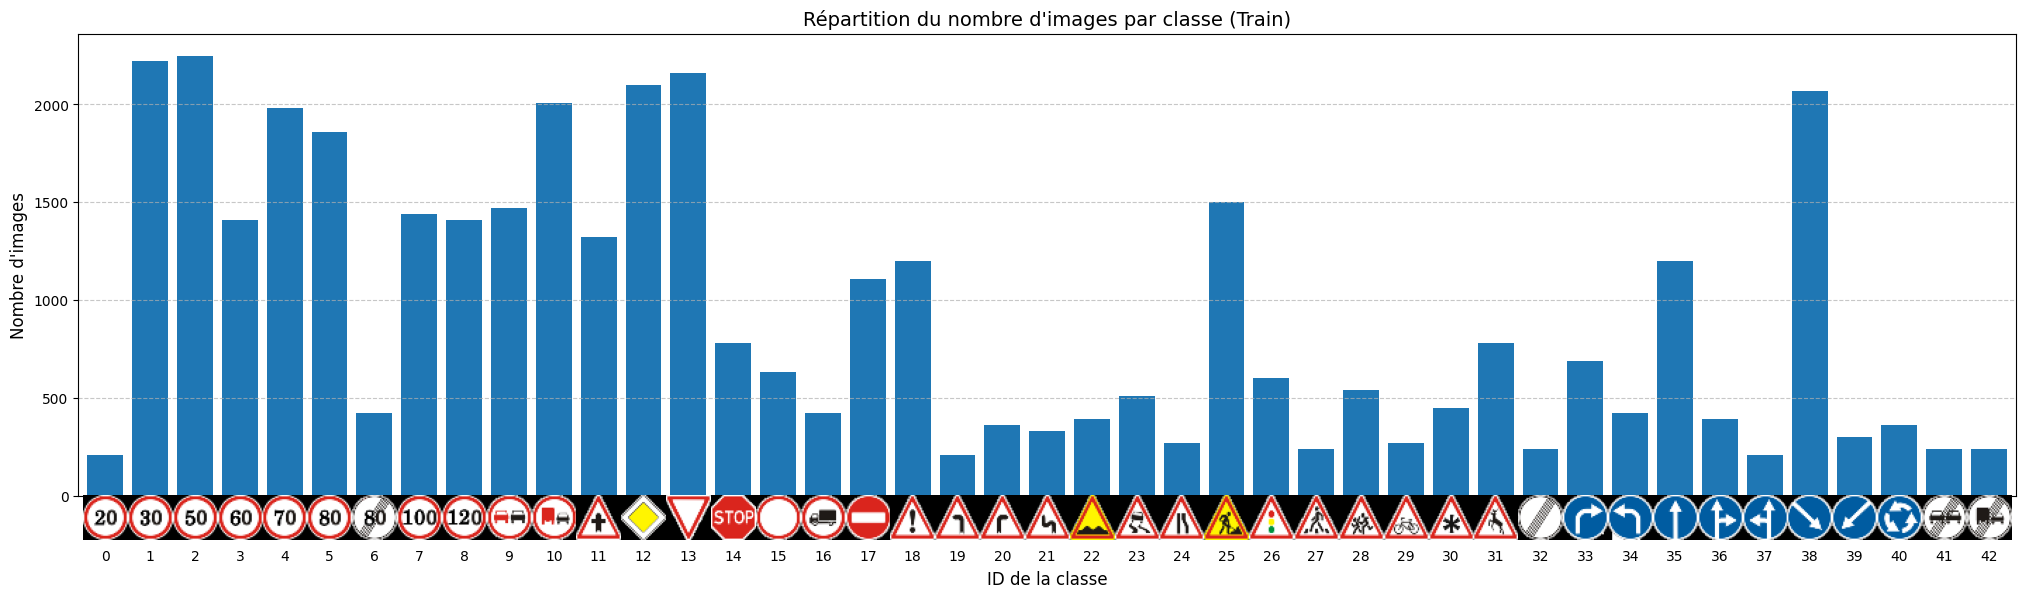

In [57]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

image_counts = {}
reference_images = {}

for class_id in range(NUM_CLASSES):
    folder_path = os.path.join(DATA_PATH_TRAIN, str(class_id))
    icon_path = os.path.join(DATA_PATH_META, f"{class_id}.png")

    if os.path.isdir(folder_path):
        num_images = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
        image_counts[class_id] = num_images

        class_name = CLASSES[class_id]
        print(f"{class_id:<4} | {class_name:<40} | {num_images}")

        # Chargement de l'icône de référence depuis le dossier Meta
        if os.path.exists(icon_path):
            img = cv2.imread(icon_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_icon = cv2.resize(img, (32, 32))
            reference_images[class_id] = img_icon
        else:
          print("Problème avec le chemin de fichiers vers les icônes")
    else:
        print("Problème avec le chemin de fichiers de la base de test")

print('\n')


# Histogramme
plt.figure(figsize=(25, 6))
ax = plt.gca() # Récupère l'axe actuel pour manipuler les icônes
ax.bar(image_counts.keys(), image_counts.values())
ax.set_title("Répartition du nombre d'images par classe (Train)", fontsize=14)
ax.set_xlabel("ID de la classe", fontsize=12, labelpad=5) # labelpad éloigne le titre de l'axe pour faire de la place
ax.set_ylabel("Nombre d'images", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
# Configuration de l'axe X pour afficher les numéros
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(range(NUM_CLASSES))
# décale les numéros vers le bas pour glisser l'image au-dessus
ax.tick_params(axis='x', pad=35)
ax.set_xlim(-0.6, NUM_CLASSES - 0.4) # réduit les marges latérales

# Placement des icônes du dossier Meta
for class_id in range(NUM_CLASSES):
    if class_id in reference_images:
        imagebox = OffsetImage(reference_images[class_id], zoom=1)
        # xybox=(0, -16) positionne l'image juste sous la ligne zéro, au-dessus du chiffre
        ab = AnnotationBbox(imagebox, (class_id, 0),
                            xybox=(0, -16),
                            xycoords='data',
                            boxcoords="offset points",
                            frameon=False)
        ax.add_artist(ab)

plt.show()

On peut observer un grand déséquilibre entre les classes, par exemple il y a 10 fois plus de limitations de vitesse à 50km qu'il n'y en a pour 20km

Chargement des images depuis /kaggle/input/gtsrb-german-traffic-sign/Train...


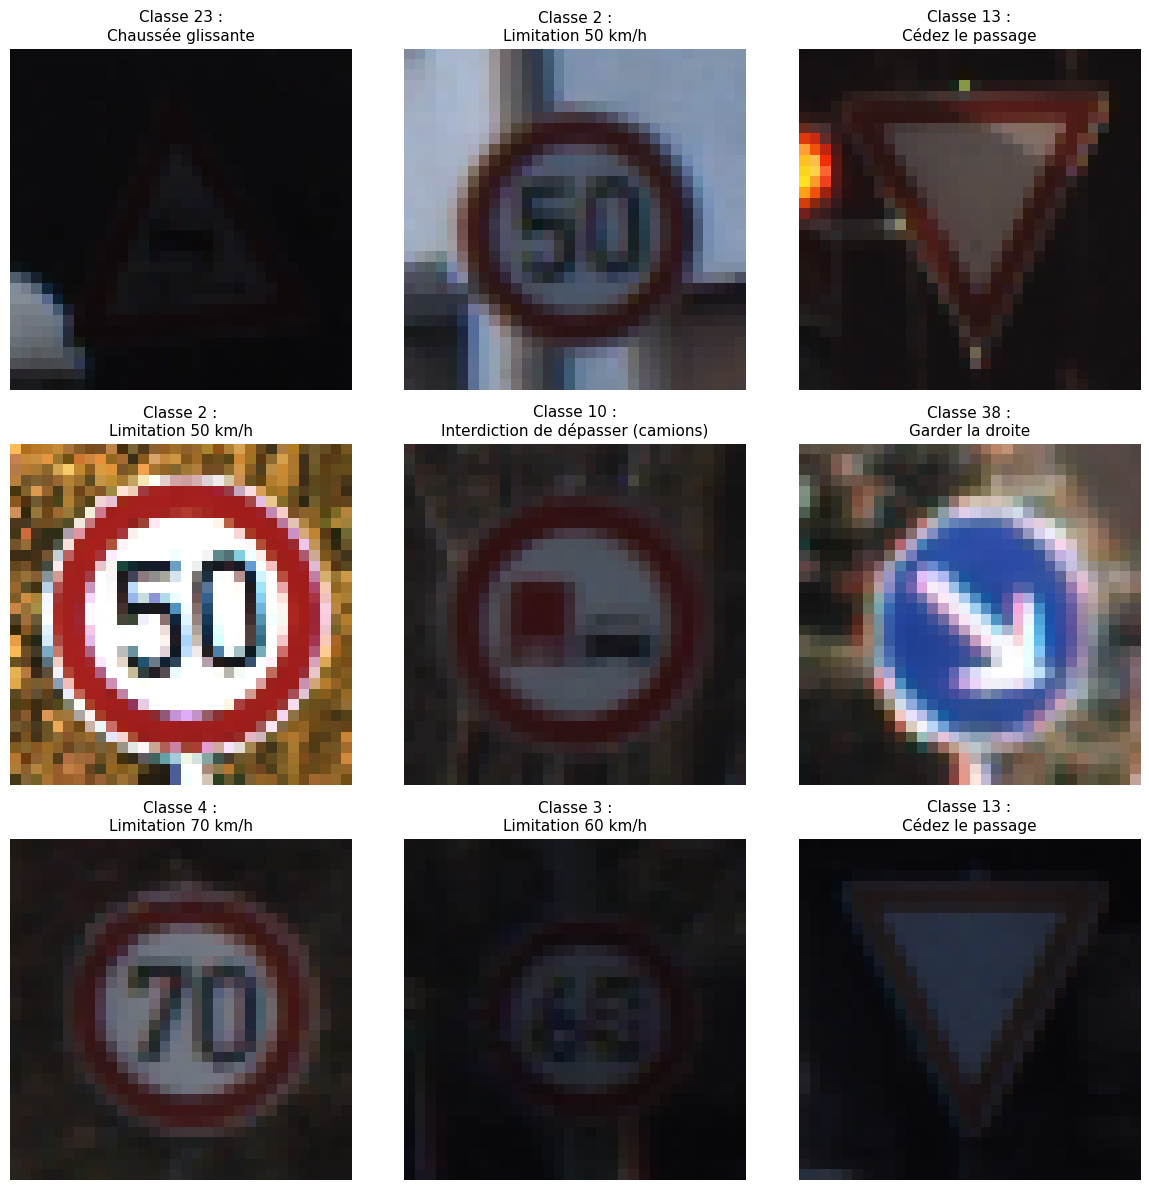

In [58]:
import numpy as np

images = []
labels = []

print(f"Chargement des images depuis {DATA_PATH_TRAIN}...")
for class_id in range(NUM_CLASSES):
    folder_path = os.path.join(DATA_PATH_TRAIN, str(class_id))

    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            if img_name.endswith('.png'):
                img_path = os.path.join(folder_path, img_name)
                img = cv2.imread(img_path)

                if img is not None:
                    # Conversion BGR (OpenCV) vers RGB (Standard)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    # Redimensionnement
                    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    images.append(img_resized)
                    labels.append(class_id)

images = np.array(images)
labels = np.array(labels)
# Affichage d'une grille de 9 images aléatoires
plt.figure(figsize=(12, 12))

# On génère 9 indices aléatoires pour piocher dans le dataset
for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Choix d'une image au hasard dans la liste globale 'images'
    idx = np.random.randint(0, len(images))

    # Affichage de l'image
    plt.imshow(images[idx])

    # Récupération de l'ID et du nom de la classe
    class_id = labels[idx]
    class_name = CLASSES[class_id]

    # Titre avec le numéro et le texte
    plt.title(f"Classe {class_id} :\n{class_name}", fontsize=11)
    plt.axis('off') # On masque les axes pour faire plus propre

plt.tight_layout()
plt.show()

## **Préparation des données**